In [ ]:
!pip install kaggle


In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

!unzip chest-xray-pneumonia.zip -d dataset


!rm chest-xray-pneumonia.zip



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open chest-xray-pneumonia.zip, chest-xray-pneumonia.zip.zip or chest-xray-pneumonia.zip.ZIP.
rm: cannot remove 'chest-xray-pneumonia.

In [ ]:
# Chest X-Ray Pneumonia Dataset Link
dataset_link = "https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia"

print("You can download the dataset from Kaggle using this link:")
print(dataset_link)


You can download the dataset from Kaggle using this link:
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


In [ ]:
import os

base_dir = "dataset/chest_xray"
print("Train:", len(os.listdir(os.path.join(base_dir, "train", "PNEUMONIA"))),
      len(os.listdir(os.path.join(base_dir, "train", "NORMAL"))))
print("Val:", len(os.listdir(os.path.join(base_dir, "val", "PNEUMONIA"))),
      len(os.listdir(os.path.join(base_dir, "val", "NORMAL"))))
print("Test:", len(os.listdir(os.path.join(base_dir, "test", "PNEUMONIA"))),
      len(os.listdir(os.path.join(base_dir, "test", "NORMAL"))))


FileNotFoundError: [Errno 2] No such file or directory: 'dataset/chest_xray/train/PNEUMONIA'

In [ ]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
data_dir = "dataset/chest_xray"
categories = ["PNEUMONIA", "NORMAL"]

data = []
labels = []


for category in categories:
    path = os.path.join(data_dir, "train", category)
    class_num = categories.index(category)
    for img_name in os.listdir(path)[:100]:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))
        data.append(img.flatten())  # Flatten the image here
        labels.append(class_num) # Append the class label here

data = np.array(data) # This should be a 2D array (samples, features)
labels = np.array(labels)

# Explicitly reshape data to be sure it's 2D (samples, features)
data = data.reshape(data.shape[0], -1)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/chest_xray/train/PNEUMONIA'

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)


In [ ]:
model = LogisticRegression(max_iter=200)
print("Shape of X_train before fitting:", X_train.shape)
model.fit(X_train, y_train)

Shape of X_train before fitting: (160, 4096)


LogisticRegression(max_iter=200)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=categories))


Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

   PNEUMONIA       0.95      0.90      0.92        20
      NORMAL       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



Accuracy: 0.9375

Classification Report:
               precision    recall  f1-score   support

   PNEUMONIA       0.91      0.97      0.94        40
      NORMAL       0.97      0.90      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



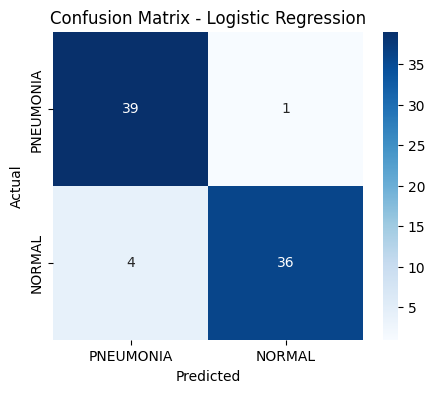

In [ ]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


data_dir = "dataset/chest_xray"
categories = ["PNEUMONIA", "NORMAL"]

data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, "train", category)
    class_num = categories.index(category)
    for img_name in os.listdir(path)[:200]:  # ناخد 200 صورة من كل class كبداية
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))
        data.append(img.flatten())
        labels.append(class_num)

data = np.array(data)
labels = np.array(labels)

# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)


# -------------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


# -------------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=categories))


# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.5323 - loss: 0.6628 - val_accuracy: 0.7250 - val_loss: 0.5236
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.8587 - loss: 0.3582 - val_accuracy: 0.9062 - val_loss: 0.2321
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.9217 - loss: 0.2065 - val_accuracy: 0.9156 - val_loss: 0.2192
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.9499 - loss: 0.1387 - val_accuracy: 0.9031 - val_loss: 0.3115
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.9546 - loss: 0.1324 - val_accuracy: 0.9250 - val_loss: 0.1784
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9673 - loss: 0.1031 - val_accuracy: 0.8594 - val_loss: 0.4961
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.9420 - loss: 0.1662 - val_accuracy: 0.9219 - val_loss: 0.2149
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.9633 - loss: 0.0855 - val_accuracy: 0.9344 - val

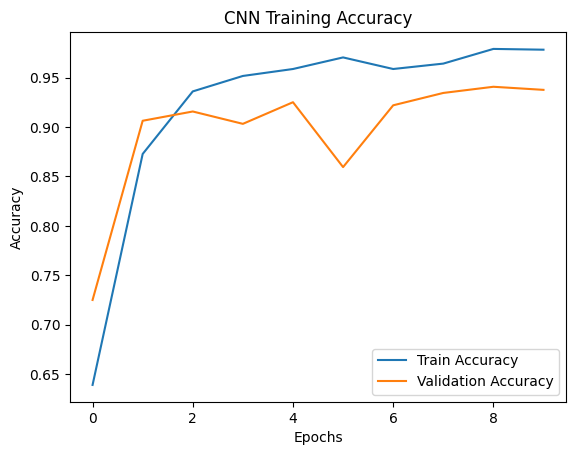

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# -------------------------------
data_dir = "dataset/chest_xray"
categories = ["PNEUMONIA", "NORMAL"]

data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, "train", category)
    class_num = categories.index(category)
    for img_name in os.listdir(path)[:1000]:  # ناخد 1000 صورة من كل class للتجربة
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))
        data.append(img)
        labels.append(class_num)

data = np.array(data).reshape(-1, 64, 64, 1) / 255.0  # Normalization
labels = to_categorical(np.array(labels), num_classes=2)


X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Training Accuracy")
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


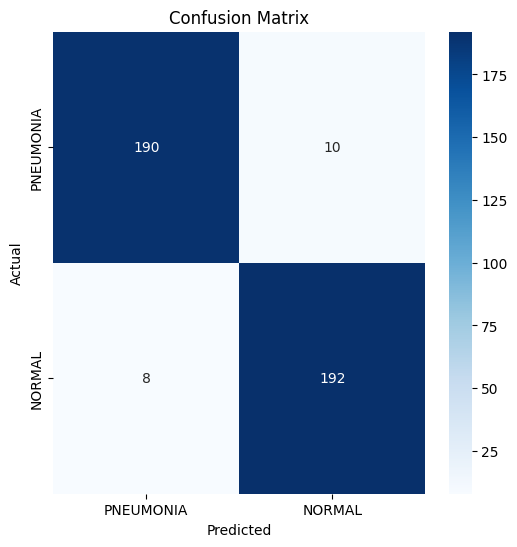

Classification Report:
              precision    recall  f1-score   support

   PNEUMONIA       0.96      0.95      0.95       200
      NORMAL       0.95      0.96      0.96       200

    accuracy                           0.95       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.95      0.95       400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=categories))


In [ ]:
!pip install streamlit pyngrok opencv-python-headless -q


In [ ]:
model.save("cnn_model.h5")


In [ ]:
pip install streamlit


In [ ]:
pip install gradio


In [ ]:
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
from PIL import Image, ImageOps


model = load_model("cnn_model.h5")
categories = ["PNEUMONIA", "NORMAL"]


def predict_image(img):

    if img.mode != "L":
        img = img.convert("L")

    img = ImageOps.fit(img, (64, 64))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # (1, 64, 64, 1)


    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return f"✅ Prediction: {categories[class_index]} (Confidence: {confidence:.2f}%)"


interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Chest X-Ray"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🧠 Medical Image Classification",
    description="ارفع صورة أشعة X-Ray والموديل هيقول إذا كانت Normal أو Pneumonia"
)

interface.launch()


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'cnn_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)